# Monitoring CatBoost v2

Май–август не участвовали ни в обучении, ни в выборе параметров или порога. Сначала посмотрим только на прогнозы, как это было бы без готового target. Затем добавим фактические ответы и оценим качество.

## 1. Прогнозы на новых бронированиях

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.inference import CancellationPredictor

production = pd.read_parquet(ROOT / "data/processed/production.parquet")
labels = production["is_canceled"].copy()
production_live = production.drop(columns="is_canceled")

predictor = CancellationPredictor()
predictions = predictor.predict_batch(production_live)
predictions.head()

,prediction,cancellation_probability,model_version
0,0,0.006174,v2
1,1,0.873782,v2
2,0,0.135835,v2
3,0,0.213074,v2
4,0,0.020282,v2


## 2. Monitoring до появления target

In [2]:
pd.Series({
    "bookings": len(predictions),
    "mean_probability": predictions["cancellation_probability"].mean(),
    "predicted_cancellation_rate": predictions["prediction"].mean(),
    "threshold": predictor.threshold,
}).round(3)

bookings                       6579.000
mean_probability                  0.226
predicted_cancellation_rate       0.220
threshold                         0.389
dtype: float64

In [3]:
monitoring = production[["booking_date"]].join(predictions)
monthly_predictions = (
    monitoring.set_index("booking_date")
    .resample("MS")
    .agg(
        bookings=("prediction", "size"),
        mean_probability=("cancellation_probability", "mean"),
        predicted_rate=("prediction", "mean"),
    )
)
monthly_predictions.round(3)

,bookings,mean_probability,predicted_rate
booking_date,,,
2017-05-01,2883,0.241,0.241
2017-06-01,1626,0.236,0.232
2017-07-01,1340,0.221,0.222
2017-08-01,730,0.151,0.103


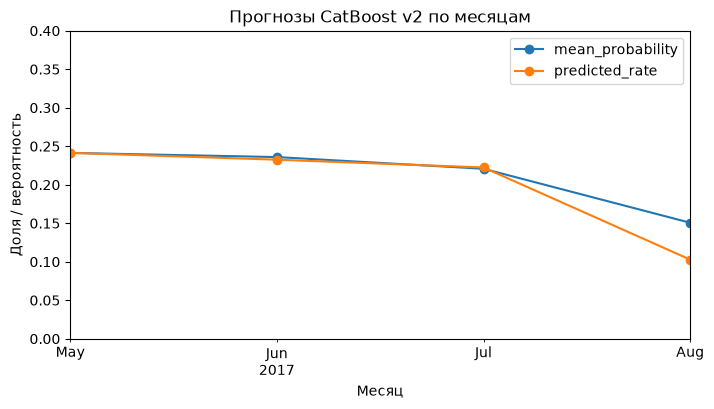

In [4]:
monthly_predictions[["mean_probability", "predicted_rate"]].plot(
    marker="o",
    figsize=(8, 4),
)
plt.title("Прогнозы CatBoost v2 по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Доля / вероятность")
plt.ylim(0, 0.4)
plt.show()

Без фактических ответов качество не измерить, зато можно заметить резкое изменение прогнозов. Здесь средняя вероятность и доля срабатываний меняются постепенно, без явного скачка.

## 3. Качество после появления target

In [5]:
probabilities = predictions["cancellation_probability"]
predicted_labels = predictions["prediction"]

production_metrics = pd.Series({
    "precision": precision_score(labels, predicted_labels),
    "recall": recall_score(labels, predicted_labels),
    "roc_auc": roc_auc_score(labels, probabilities),
    "pr_auc": average_precision_score(labels, probabilities),
})
production_metrics.round(3)

precision    0.661
recall       0.540
roc_auc      0.859
pr_auc       0.685
dtype: float64

In [6]:
quality_data = production[["booking_date", "is_canceled"]].join(predictions)
monthly_quality = (
    quality_data.groupby(quality_data["booking_date"].dt.to_period("M"))
    .apply(
        lambda month: pd.Series({
            "bookings": len(month),
            "actual_rate": month["is_canceled"].mean(),
            "predicted_rate": month["prediction"].mean(),
            "precision": precision_score(
                month["is_canceled"], month["prediction"], zero_division=0
            ),
            "recall": recall_score(
                month["is_canceled"], month["prediction"], zero_division=0
            ),
        }),
        include_groups=False,
    )
)
monthly_quality.round(3)

,bookings,actual_rate,predicted_rate,precision,recall
booking_date,,,,,
2017-05,2883.0,0.290,0.241,0.658,0.549
2017-06,1626.0,0.282,0.232,0.680,0.561
2017-07,1340.0,0.270,0.222,0.648,0.533
2017-08,730.0,0.159,0.103,0.653,0.422


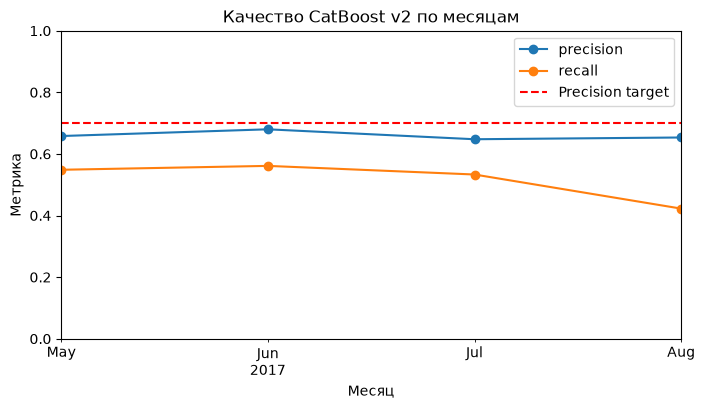

In [7]:
monthly_quality[["precision", "recall"]].plot(marker="o", figsize=(8, 4))
plt.axhline(0.70, color="red", linestyle="--", label="Precision target")
plt.title("Качество CatBoost v2 по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Метрика")
plt.ylim(0, 1)
plt.legend()
plt.show()

## 4. Простая проверка drift

In [8]:
test = pd.read_parquet(ROOT / "data/processed/test.parquet")
april = test[test["booking_date"].dt.month == 4]

drift = pd.DataFrame({
    "april": {
        "cancellation_rate": april["is_canceled"].mean(),
        "lead_time_median": april["lead_time"].median(),
        "adr_median": april["adr"].median(),
        "non_refund_share": april["deposit_type"].eq("Non Refund").mean(),
    },
    "may–august": {
        "cancellation_rate": production["is_canceled"].mean(),
        "lead_time_median": production["lead_time"].median(),
        "adr_median": production["adr"].median(),
        "non_refund_share": production["deposit_type"].eq("Non Refund").mean(),
    },
})
drift.round(3)

,april,may–august
cancellation_rate,0.311,0.269
lead_time_median,31.000,17.000
adr_median,133.405,144.000
non_refund_share,0.014,0.007


## Итог

На независимом периоде модель по-прежнему неплохо ранжирует бронирования, но Precision снова ниже бизнес-цели. Подгонять порог по этим же данным нельзя.

Пока логичный следующий шаг — накопить свежие ответы, подробнее проверить drift и только потом решать, нужно ли новое переобучение.